# Real GDP Analysis

EDA, ARIMA forecasting, and K-means clustering of real GDP trajectories across six countries.

**Data source:** World Bank real GDP (constant 2015 USD), reshaped from the raw World Bank CSV into long format.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load Data

Reads the long-format CSV (one row per country-year) and computes log GDP and annual growth rate.

In [2]:
df = pd.read_csv('../data/real_gdp_data_six_countries.csv')
df = df.sort_values(['Country Name', 'Year']).reset_index(drop=True)
df['log_gdp'] = np.log(df['Real GDP (2015 $)'])
df['gdp_growth_pct'] = (
    df.groupby('Country Name')['Real GDP (2015 $)'].pct_change(fill_method=None) * 100
)
print(df.shape)
df.head(10)

(396, 6)


,Country Name,Country Code,Year,Real GDP (2015 $),log_gdp,gdp_growth_pct
0,China,CHN,1960,1.610230e+11,25.804813,NaN
1,China,CHN,1961,1.171120e+11,25.486397,-27.270017
2,China,CHN,1962,1.105770e+11,25.428978,-5.580128
3,China,CHN,1963,1.219670e+11,25.527016,10.300515
4,China,CHN,1964,1.441400e+11,25.694051,18.179508
5,China,CHN,1965,1.685720e+11,25.850629,16.950187
6,China,CHN,1966,1.865250e+11,25.951831,10.650049
7,China,CHN,1967,1.757620e+11,25.892397,-5.770272
8,China,CHN,1968,1.685560e+11,25.850534,-4.099862
9,China,CHN,1969,1.971100e+11,26.007028,16.940364


## 3. Exploratory Data Analysis

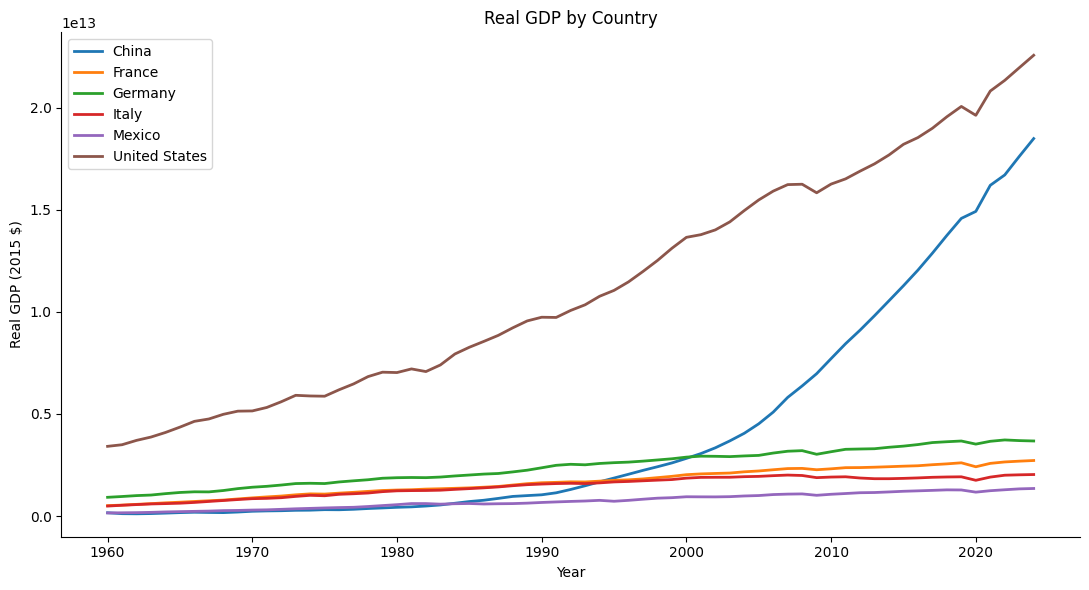

In [3]:
# GDP levels
fig, ax = plt.subplots()
for country, sub in df.groupby('Country Name'):
    ax.plot(sub['Year'], sub['Real GDP (2015 $)'], linewidth=2, label=country)
ax.set_title('Real GDP by Country')
ax.set_xlabel('Year')
ax.set_ylabel('Real GDP (2015 $)')
ax.legend()
plt.tight_layout()
plt.show()

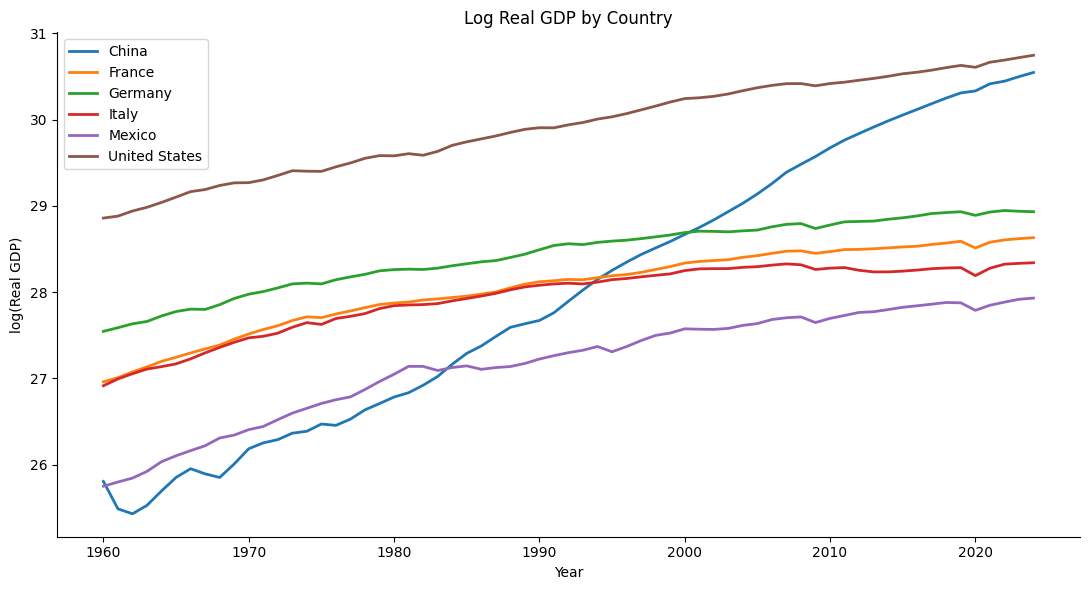

In [4]:
# Log GDP levels — easier to compare growth rates visually
fig, ax = plt.subplots()
for country, sub in df.groupby('Country Name'):
    ax.plot(sub['Year'], sub['log_gdp'], linewidth=2, label=country)
ax.set_title('Log Real GDP by Country')
ax.set_xlabel('Year')
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

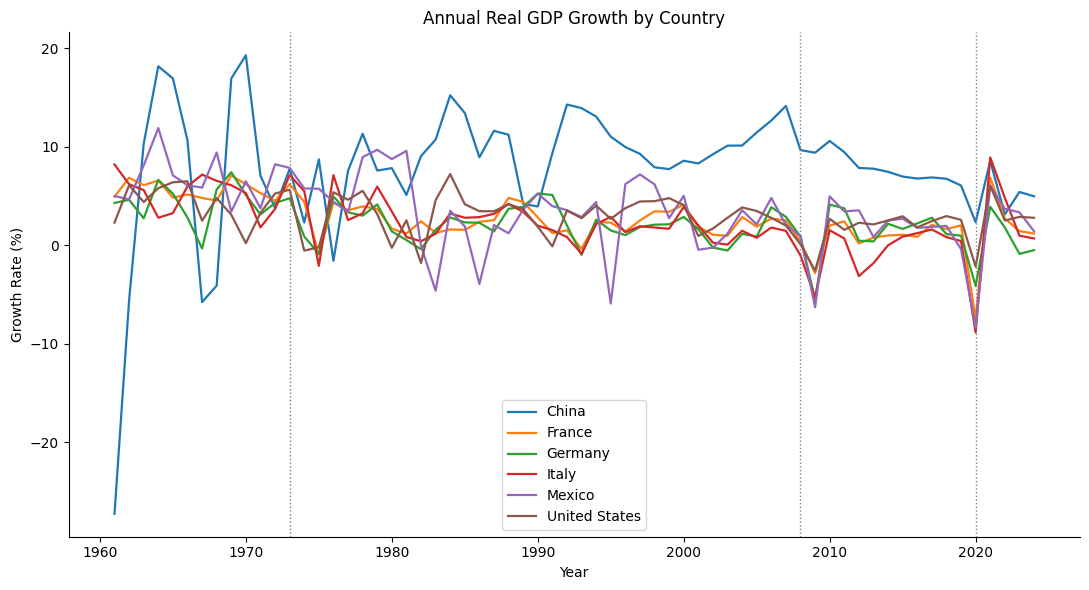

In [5]:
# Annual growth rates with major shock markers
fig, ax = plt.subplots()
for country, sub in df.groupby('Country Name'):
    ax.plot(sub['Year'], sub['gdp_growth_pct'], linewidth=1.6, label=country)
for shock_year in [1973, 2008, 2020]:
    ax.axvline(shock_year, color='gray', linestyle=':', linewidth=1)
ax.set_title('Annual Real GDP Growth by Country')
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Growth Summary Statistics

In [6]:
summary = (
    df.groupby('Country Name')
    .agg(
        start_year=('Year', 'min'),
        end_year=('Year', 'max'),
        latest_gdp=('Real GDP (2015 $)', 'last'),
        mean_growth_pct=('gdp_growth_pct', 'mean'),
        median_growth_pct=('gdp_growth_pct', 'median'),
        growth_volatility=('gdp_growth_pct', 'std'),
        min_growth_pct=('gdp_growth_pct', 'min'),
        max_growth_pct=('gdp_growth_pct', 'max'),
    )
    .round(3)
    .reset_index()
)
summary

,Country Name,start_year,end_year,latest_gdp,mean_growth_pct,median_growth_pct,growth_volatility,min_growth_pct,max_growth_pct
0,China,1960,2025,1.848810e+13,7.921,8.653,6.632,-27.270,19.300
1,France,1960,2025,2.720360e+12,2.676,2.440,2.408,-7.441,7.094
2,Germany,1960,2025,3.677050e+12,2.218,2.201,2.305,-5.545,7.418
3,Italy,1960,2025,2.033590e+12,2.299,1.872,3.065,-8.868,8.931
4,Mexico,1960,2025,1.350020e+12,3.542,3.567,3.876,-8.354,11.905
5,United States,1960,2025,2.256850e+13,3.016,2.956,2.084,-2.576,7.236


## 5. Growth by Period

Average annual growth split into four eras: pre-1990, 1990–2007, 2008–2019, 2020–2025.

In [7]:
def period_label(year):
    if year <= 1989: return '1960-1989'
    if year <= 2007: return '1990-2007'
    if year <= 2019: return '2008-2019'
    return '2020-2025'

period_df = df.dropna(subset=['gdp_growth_pct']).copy()
period_df['period'] = period_df['Year'].map(period_label)
period_growth = (
    period_df.groupby(['Country Name', 'period'])['gdp_growth_pct']
    .mean().round(3).reset_index()
    .pivot(index='Country Name', columns='period', values='gdp_growth_pct')
    .reset_index()
)
period_growth

period,Country Name,1960-1989,1990-2007,2008-2019,2020-2025
0,China,6.951,10.291,7.975,4.887
1,France,4.002,2.154,0.970,0.958
2,Germany,3.154,1.955,1.256,0.044
3,Italy,4.057,1.501,-0.339,1.310
4,Mexico,5.103,3.033,1.492,1.237
5,United States,3.638,2.995,1.792,2.417


## 6. ARIMA Forecasting

For each country, select the best ARIMA(p,d,q) order by AIC on a training window, then forecast the held-out last 6 years of log GDP.

**Interpretation:** Low MAE/RMSE means the model tracks the country's trend well. ARIMA is a purely univariate model — it cannot explain *why* GDP grows, only extrapolate the past pattern.

In [8]:
def choose_arima_order(series, p_range=range(0,3), d_range=range(0,3), q_range=range(0,3)):
    best_order, best_aic = (1,1,0), np.inf
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    fit = ARIMA(series, order=(p,d,q)).fit()
                    if np.isfinite(fit.aic) and fit.aic < best_aic:
                        best_aic, best_order = fit.aic, (p,d,q)
                except Exception:
                    continue
    return best_order

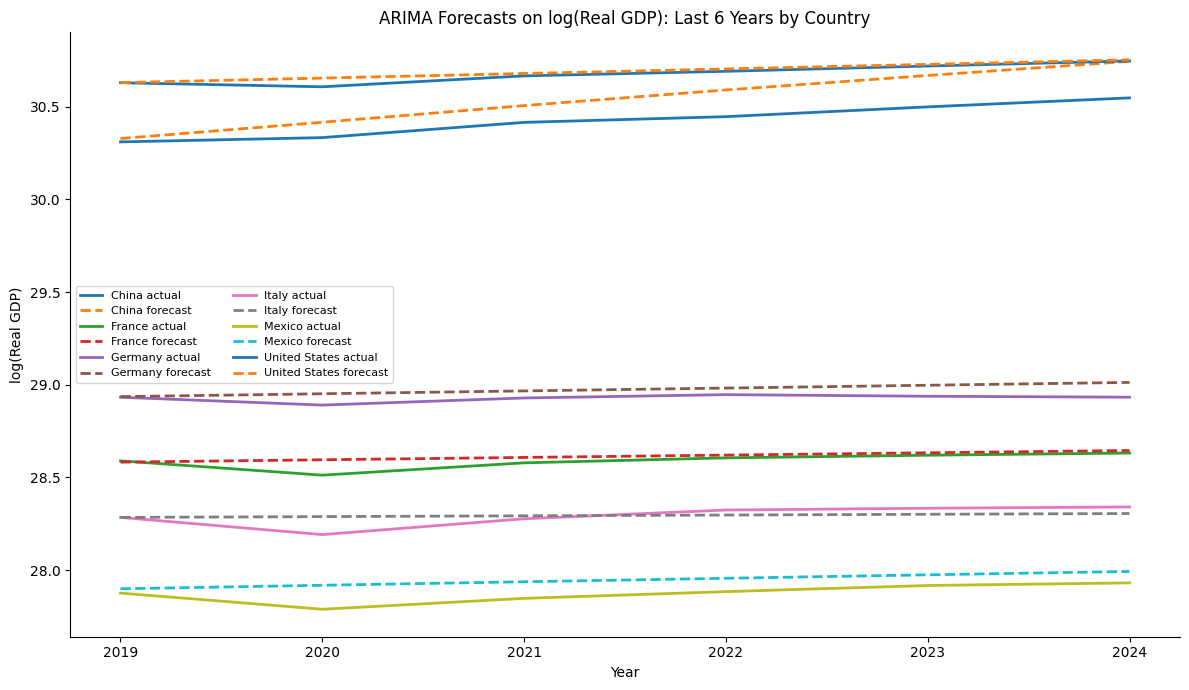

,Country,Order,Train end,Test start,MAE (log GDP),RMSE (log GDP),AIC
0,China,"(2, 2, 1)",2018,2019,0.1170,0.1314,-161.59
1,France,"(1, 1, 2)",2018,2019,0.0268,0.0374,-315.44
2,Germany,"(1, 1, 2)",2018,2019,0.0462,0.0522,-279.15
3,Italy,"(1, 1, 1)",2018,2019,0.0347,0.0461,-277.65
4,Mexico,"(1, 1, 1)",2018,2019,0.0722,0.0792,-221.91
5,United States,"(1, 1, 2)",2018,2019,0.0147,0.0211,-284.76


In [9]:
test_horizon = 6
arima_rows = []
fig, ax = plt.subplots(figsize=(12, 7))

for country, sub in df.groupby('Country Name'):
    sub = sub.sort_values('Year').dropna(subset=['log_gdp'])
    periods = pd.PeriodIndex(sub['Year'].astype(int), freq='Y')
    ts = pd.Series(sub['log_gdp'].to_numpy(), index=periods)

    train, test = ts.iloc[:-test_horizon], ts.iloc[-test_horizon:]
    order = choose_arima_order(train)
    fitted = ARIMA(train, order=order).fit()
    forecast = fitted.get_forecast(steps=test_horizon).predicted_mean

    arima_rows.append({'Country': country, 'Order': str(order),
                       'Train end': int(train.index.max().year),
                       'Test start': int(test.index.min().year),
                       'MAE (log GDP)': round(float(np.mean(np.abs(test - forecast))), 4),
                       'RMSE (log GDP)': round(float(np.sqrt(np.mean((test - forecast)**2))), 4),
                       'AIC': round(float(fitted.aic), 2)})

    ax.plot(test.index.year, test.values, linewidth=2, label=f'{country} actual')
    ax.plot(test.index.year, forecast.values, linestyle='--', linewidth=2, label=f'{country} forecast')

ax.set_title('ARIMA Forecasts on log(Real GDP): Last 6 Years by Country')
ax.set_xlabel('Year')
ax.set_ylabel('log(Real GDP)')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

arima_metrics = pd.DataFrame(arima_rows)
arima_metrics

## 7. K-means Clustering

Group countries by their GDP growth profile using features: mean growth, volatility, pre/post-2000 growth, crisis-era growth, and long-run trend.

**Note:** With only 6 countries, clusters are illustrative — don't over-interpret boundaries.

In [10]:
feature_rows = []
for country, sub in df.dropna(subset=['gdp_growth_pct']).groupby('Country Name'):
    sub = sub.sort_values('Year')
    pre   = sub[sub['Year'] <= 1999]['gdp_growth_pct']
    post  = sub[sub['Year'] >= 2000]['gdp_growth_pct']
    crisis = sub[sub['Year'].between(2008, 2009)]['gdp_growth_pct']
    covid  = sub[sub['Year'].between(2020, 2021)]['gdp_growth_pct']
    X, y  = sub['Year'].to_numpy(dtype=float), sub['gdp_growth_pct'].to_numpy(dtype=float)
    trend = float(np.polyfit(X, y, 1)[0]) if len(np.unique(X)) > 1 else np.nan
    feature_rows.append({
        'Country Name':      country,
        'latest_log_gdp':    float(sub['log_gdp'].iloc[-1]),
        'mean_growth_pct':   float(sub['gdp_growth_pct'].mean()),
        'growth_volatility': float(sub['gdp_growth_pct'].std()),
        'pre_2000_growth':   float(pre.mean())    if len(pre)    else np.nan,
        'post_2000_growth':  float(post.mean())   if len(post)   else np.nan,
        'crisis_2008_growth':float(crisis.mean()) if len(crisis) else np.nan,
        'covid_growth':      float(covid.mean())  if len(covid)  else np.nan,
        'growth_trend':      trend,
    })

feature_df = pd.DataFrame(feature_rows)
numeric_cols = [c for c in feature_df.columns if c != 'Country Name']
feature_df[numeric_cols] = feature_df[numeric_cols].apply(lambda col: col.fillna(col.mean()))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df[numeric_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
feature_df['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, feature_df['cluster'])
print(f'Silhouette score: {sil:.3f}')
feature_df[['Country Name', 'cluster', 'mean_growth_pct', 'growth_volatility', 'post_2000_growth']]

Silhouette score: 0.347


,Country Name,cluster,mean_growth_pct,growth_volatility,post_2000_growth
0,China,1,7.920941,6.632000,8.192393
1,France,2,2.675655,2.408403,1.380254
2,Germany,2,2.217781,2.304525,1.114122
3,Italy,2,2.299283,3.065169,0.568353
4,Mexico,2,3.541602,3.875672,1.686899
5,United States,0,3.015676,2.083516,2.209386


In [11]:
cluster_summary = (
    feature_df.groupby('cluster')
    .agg(countries=('Country Name', lambda x: ', '.join(sorted(x))),
         mean_growth=('mean_growth_pct', 'mean'),
         volatility=('growth_volatility', 'mean'),
         post_2000_growth=('post_2000_growth', 'mean'))
    .round(3).reset_index()
)
cluster_summary

,cluster,countries,mean_growth,volatility,post_2000_growth
0,0,United States,3.016,2.084,2.209
1,1,China,7.921,6.632,8.192
2,2,"France, Germany, Italy, Mexico",2.684,2.913,1.187


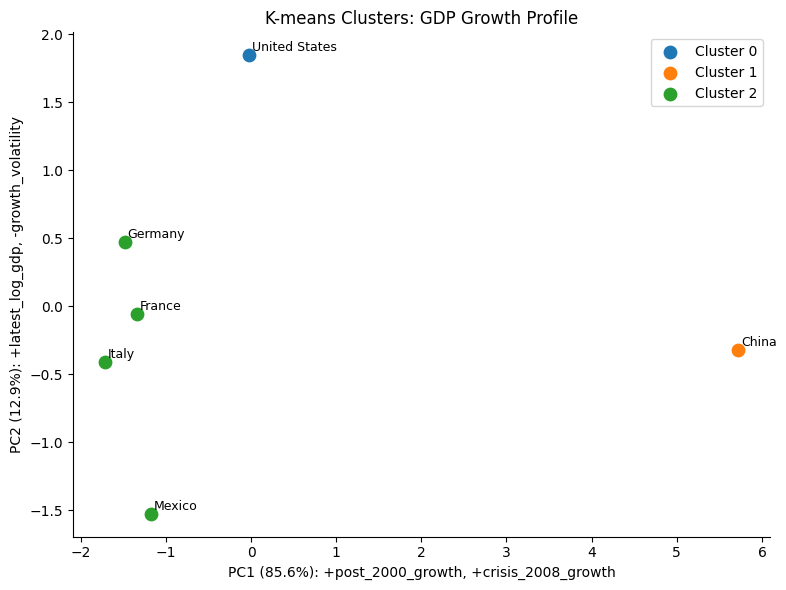

In [12]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
loadings = pd.DataFrame(pca.components_.T, index=numeric_cols, columns=['PC1','PC2'])

def pc_label(pc_name):
    top = loadings[pc_name].sort_values(key=lambda s: s.abs(), ascending=False).head(2)
    parts = [f"{'+'if v>=0 else '-'}{i}" for i,v in top.items()]
    pct = pca.explained_variance_ratio_[0 if pc_name=='PC1' else 1]*100
    return f"{pc_name} ({pct:.1f}%): " + ", ".join(parts)

plot_df = feature_df.copy()
plot_df['pc1'], plot_df['pc2'] = coords[:,0], coords[:,1]

fig, ax = plt.subplots(figsize=(8,6))
cmap = plt.get_cmap('tab10')
for cluster in sorted(plot_df['cluster'].unique()):
    sub = plot_df[plot_df['cluster']==cluster]
    ax.scatter(sub['pc1'], sub['pc2'], s=80, color=cmap(cluster), label=f'Cluster {cluster}')
    for _, row in sub.iterrows():
        ax.text(row['pc1']+0.03, row['pc2']+0.03, row['Country Name'], fontsize=9)
ax.set_title('K-means Clusters: GDP Growth Profile')
ax.set_xlabel(pc_label('PC1'))
ax.set_ylabel(pc_label('PC2'))
ax.legend()
plt.tight_layout()
plt.show()

## 8. PCA Loadings

Shows which features drive each principal component.

In [13]:
loadings.round(3)

,PC1,PC2
latest_log_gdp,0.267,0.689
mean_growth_pct,0.373,-0.198
growth_volatility,0.334,-0.463
pre_2000_growth,0.356,-0.336
post_2000_growth,0.381,-0.057
crisis_2008_growth,0.377,-0.036
covid_growth,0.365,0.258
growth_trend,0.361,0.293


## Findings

**EDA and growth rates (Sections 3–5):**
China's mean growth (~9%) is roughly 3× the other five countries and dominates any pooled analysis. The 2008 financial crisis and 2020 COVID shock are clearly visible across all countries, though the depth and recovery speed vary. Growth volatility has generally declined in the post-2000 period for most countries, except for the two large shocks.

**Period averages (Section 5):**
All six countries show lower average growth in 2008–2019 compared to 1990–2007, consistent with the "secular stagnation" narrative in the post-crisis period. The 2020–2025 period shows sharp drops followed by recovery, but averages mask the V-shape.

**ARIMA forecasting (Section 6):**
The models track the overall trend well (low MAE on log GDP) but ARIMA is purely extrapolating past momentum — it has no information about shocks. The practical value here is confirming that GDP growth is highly persistent within countries: knowing where a country has been is a strong predictor of where it's going in the short run.

**K-means clustering (Section 7):**
With only 6 countries, the clusters are illustrative rather than definitive. The model tends to isolate China (high mean growth, declining trend, high volatility) from the mature Western economies (lower but stable growth). Mexico and India often bridge the groups depending on which features dominate. The silhouette score reflects that 6 data points don't support strong cluster separation.

**Bottom line:** This is a descriptive analysis of six well-studied economies. The main value is as context for the renewables work — understanding baseline economic trajectories for the same countries helps interpret why their energy mixes evolve differently.